# Measuring Explanation Faithfulness: A Multi-Dataset Benchmark

How faithful are local DPG explanations? Do they accurately reflect what the model actually does?

In this notebook, we benchmark the **faithfulness** of DPG explanations across four diverse datasets:
- **Iris** — small, low-dimensional, well-separable
- **Wine** — moderate size, 13 chemical features
- **Breast Cancer** — large, high-dimensional (30 features), medical data
- **Wheat Seeds** — morphological measurements, 7 features

We'll measure faithfulness using four key metrics and visualize how explanation quality varies across datasets and samples.

## What is Explanation Faithfulness?

**Faithfulness** asks: *Does the explanation accurately represent what the model does?*

We measure it using four dimensions:

1. **Output Fidelity** — Does the DPG majority vote match the model's prediction? (0-1, higher is better)
   - The explanation should make the same decision as the model

2. **Trace Coverage** — Do the extracted decision paths cover the actual execution path? (0-1, higher is better)
   - Computed from node recall (do we capture the right predicates?) and edge recall (do we capture the right transitions?)

3. **Anti-Recombination** — Are there spurious edges in the explanation path that weren't actually executed? (0-1, higher is better)
   - Low recombination means the explanation doesn't invent extra decision steps

4. **Evidence Margin** — How clear is the distinction between the winning class and runner-ups? (0-1, higher is better)
   - A large margin means the evidence strongly supports one class

The final **faithfulness score** is a weighted combination of these four metrics (default: 0.35 × fidelity + 0.30 × coverage + 0.20 × anti-recombination + 0.15 × margin).

## Setup

In [10]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

from dpg import DPGExplainer

# Set style
sns.set_style('whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Load All Datasets

We'll load four datasets, normalizing their structure for consistent processing.

In [11]:
datasets = {}

# 1. Iris
iris = load_iris(as_frame=True)
datasets['iris'] = {
    'X': iris.data.values,
    'y': iris.target.values,
    'feature_names': iris.feature_names,
    'target_names': iris.target_names.tolist(),
}

# 2. Wine
wine = load_wine(as_frame=True)
datasets['wine'] = {
    'X': wine.data.values,
    'y': wine.target.values,
    'feature_names': wine.feature_names,
    'target_names': wine.target_names.tolist(),
}

# 3. Breast Cancer
cancer = load_breast_cancer(as_frame=True)
datasets['breast_cancer'] = {
    'X': cancer.data.values,
    'y': cancer.target.values,
    'feature_names': cancer.feature_names,
    'target_names': cancer.target_names.tolist(),
}

# 4. Wheat Seeds (from UCI ML Repository)
print("Loading wheat seeds dataset from UCI ML Repository...")
WHEAT_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"
col_names = [
    'area', 'perimeter', 'compactness',
    'kernel_length', 'kernel_width',
    'asymmetry_coeff', 'groove_length', 'variety'
]
wheat_raw = pd.read_csv(WHEAT_URL, sep=r'\s+', header=None, names=col_names)
wheat_y = wheat_raw['variety'].values - 1  # Remap 1,2,3 -> 0,1,2
wheat_X = wheat_raw[col_names[:-1]].values

datasets['wheat_seeds'] = {
    'X': wheat_X,
    'y': wheat_y,
    'feature_names': col_names[:-1],
    'target_names': ['Kama', 'Rosa', 'Canadian'],
}

# Print summary
print("\nDataset Summary:")
print(f"{'Dataset':<20} {'Samples':<12} {'Features':<12} {'Classes':<10}")
print("-" * 54)
for name, data in datasets.items():
    n_samples, n_features = data['X'].shape
    n_classes = len(data['target_names'])
    print(f"{name:<20} {n_samples:<12} {n_features:<12} {n_classes:<10}")

Loading wheat seeds dataset from UCI ML Repository...

Dataset Summary:
Dataset              Samples      Features     Classes   
------------------------------------------------------
iris                 150          4            3         
wine                 178          13           3         
breast_cancer        569          30           2         
wheat_seeds          210          7            3         


## Benchmark: Evaluate Faithfulness Across All Datasets

For each dataset, we will:
1. Train a Random Forest classifier
2. Fit a DPG explainer
3. Evaluate faithfulness on all samples
4. Store results for comparison

In [12]:
# Run benchmark for all datasets
results = {}

for dataset_name, data in datasets.items():
    print(f"\n{'='*60}")
    print(f"Benchmarking: {dataset_name.upper()}")
    print(f"{'='*60}")
    
    X, y = data['X'], data['y']
    feature_names = data['feature_names']
    target_names = data['target_names']
    
    # Train model
    print(f"Training RandomForest...")
    model = RandomForestClassifier(
        n_estimators=10,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    model.fit(X, y)
    train_acc = model.score(X, y)
    print(f"  Training accuracy: {train_acc:.3f}")
    
    # Fit DPG explainer
    print(f"Fitting DPG explainer...")
    explainer = DPGExplainer(
        model=model,
        feature_names=feature_names,
        target_names=target_names,
        dpg_config={
            "dpg": {
                "default": {
                    "perc_var": 1e-9,
                    "decimal_threshold": 6,
                    "n_jobs": 1,
                },
                "graph_construction": {
                    "mode": "execution_trace",
                },
            }
        },
    )
    explainer.fit(X)
    
    # Evaluate faithfulness
    print(f"Evaluating faithfulness on {len(X)} samples...")
    faith_results = explainer.evaluate_faithfulness(
        X=X,
        y_true=y,
        return_details=True,
    )
    
    results[dataset_name] = faith_results
    
    # Print summary
    print(f"\n  Composite Faithfulness Score: {faith_results['faithfulness_score']:.4f}")
    print(f"  Output Fidelity: {faith_results['output_fidelity']:.4f}")
    print(f"  Mean Trace Coverage: {faith_results['mean_trace_coverage_score']:.4f}")
    print(f"  Mean (1 - Recombination): {1 - faith_results['mean_recombination_rate']:.4f}")
    print(f"  Mean Evidence Margin: {faith_results['mean_evidence_score_margin']:.4f}")
    print(f"  Successful evaluations: {faith_results['n_successful']} / {faith_results['n_samples']}")

print(f"\n{'='*60}")
print("✓ Benchmark complete")


Benchmarking: IRIS
Training RandomForest...
  Training accuracy: 1.000
Fitting DPG explainer...
DPG initialized with perc_var=1e-09, decimal_threshold=6, n_jobs=1, graph_construction_mode=execution_trace

Starting DPG extraction *****************************************
Model Class: RandomForestClassifier
Model Class Module: sklearn.ensemble._forest
Model Estimators:  10
Model Params:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': 1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
*****************************************************************


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:00<00:00, 218605.14it/s]


Total of paths: 1500
Building DPG...


Processing cases: 100%|███████████████████████████████████████████████████████████████████████████████| 1500/1500 [00:00<00:00, 6204.39it/s]


Extracting graph...
Evaluating faithfulness on 150 samples...

  Composite Faithfulness Score: 0.9926
  Output Fidelity: 1.0000
  Mean Trace Coverage: 1.0000
  Mean (1 - Recombination): 1.0000
  Mean Evidence Margin: 0.9507
  Successful evaluations: 150 / 150

Benchmarking: WINE
Training RandomForest...
  Training accuracy: 1.000
Fitting DPG explainer...
DPG initialized with perc_var=1e-09, decimal_threshold=6, n_jobs=1, graph_construction_mode=execution_trace

Starting DPG extraction *****************************************
Model Class: RandomForestClassifier
Model Class Module: sklearn.ensemble._forest
Model Estimators:  10
Model Params:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': 1, 'oob_score': False

...

Extracting graph...
Evaluating faithfulness on 569 samples...

  Composite Faithfulness Score: 0.9907
  Output Fidelity: 0.9982
  Mean Trace Coverage: 1.0000
  Mean (1 - Recombination): 1.0000
  Mean Evidence Margin: 0.9424
  Successful evaluations: 569 / 569

Benchmarking: WHEAT_SEEDS
Training RandomForest...
  Training accuracy: 0.981
Fitting DPG explainer...
DPG initialized with perc_var=1e-09, decimal_threshold=6, n_jobs=1, graph_construction_mode=execution_trace

Starting DPG extraction *****************************************
Model Class: RandomForestClassifier
Model Class Module: sklearn.ensemble._forest
Model Estimators:  10
Model Params:  {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 10, 'n_jobs': 1, 'oob_score'

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 210/210 [00:00<00:00, 383959.83it/s]


Total of paths: 2100
Building DPG...


Processing cases: 100%|███████████████████████████████████████████████████████████████████████████████| 2100/2100 [00:00<00:00, 6265.65it/s]


Extracting graph...
Evaluating faithfulness on 210 samples...

  Composite Faithfulness Score: 0.9837
  Output Fidelity: 0.9952
  Mean Trace Coverage: 1.0000
  Mean (1 - Recombination): 1.0000
  Mean Evidence Margin: 0.9024
  Successful evaluations: 210 / 210

✓ Benchmark complete


## Result 1: Composite Faithfulness Score Comparison

The composite faithfulness score (0-1) summarizes overall explanation quality. Higher is better.

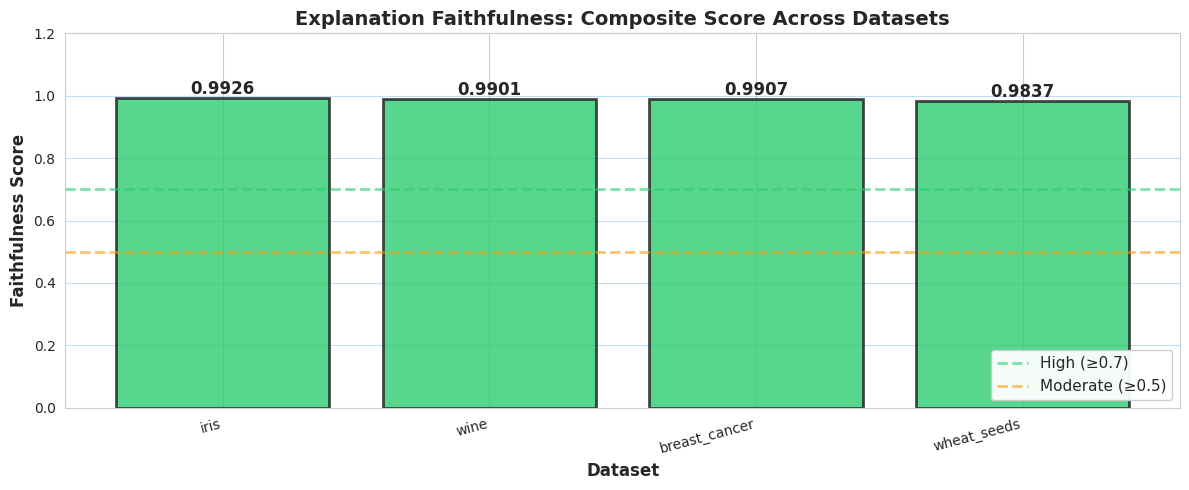


Composite Faithfulness Scores:
  iris                : 0.9926
  breast_cancer       : 0.9907
  wine                : 0.9901
  wheat_seeds         : 0.9837


In [13]:
# Extract composite scores
composite_scores = {
    name: results[name]['faithfulness_score']
    for name in results.keys()
}

# Create bar chart with DPG colors
fig, ax = plt.subplots(figsize=(12, 5))

datasets_list = list(composite_scores.keys())
scores_list = list(composite_scores.values())

# Use DPG color scheme: success (≥0.7), warning (0.5-0.7), danger (<0.5)
colors_bar = ['#2ECC71' if s >= 0.7 else '#F39C12' if s >= 0.5 else '#E74C3C' for s in scores_list]

bars = ax.bar(datasets_list, scores_list, color=colors_bar, alpha=0.8, edgecolor='#1C1C1C', linewidth=2)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Faithfulness Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_title('Explanation Faithfulness: Composite Score Across Datasets', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, color='#3498DB')

# Add value labels
for bar, score in zip(bars, scores_list):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Add reference lines with DPG colors
ax.axhline(y=0.7, color='#2ECC71', linestyle='--', alpha=0.6, linewidth=2, label='High (≥0.7)')
ax.axhline(y=0.5, color='#F39C12', linestyle='--', alpha=0.6, linewidth=2, label='Moderate (≥0.5)')
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print("\nComposite Faithfulness Scores:")
for name, score in sorted(composite_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:<20}: {score:.4f}")


## Result 2: Detailed Metric Breakdown

Let's compare the four faithfulness components side-by-side across datasets.

In [14]:
# Extract metric data for all datasets
metrics_comparison = []

metric_keys = [
    ('output_fidelity', 'Output Fidelity'),
    ('mean_trace_coverage_score', 'Trace Coverage'),
    ('mean_recombination_rate', 'Recombination Rate'),
    ('mean_evidence_score_margin', 'Evidence Margin'),
]

for dataset_name in results.keys():
    row = {'Dataset': dataset_name}
    res = results[dataset_name]
    
    for key, label in metric_keys:
        value = res.get(key, 0)
        # Invert recombination rate so higher is always better
        if key == 'mean_recombination_rate':
            value = 1.0 - value
        row[label] = value
    
    metrics_comparison.append(row)

metrics_df = pd.DataFrame(metrics_comparison)

print("\nDetailed Faithfulness Metrics (all scaled 0-1, higher is better):")
print(metrics_df.to_string(index=False))


Detailed Faithfulness Metrics (all scaled 0-1, higher is better):
      Dataset  Output Fidelity  Trace Coverage  Recombination Rate  Evidence Margin
         iris         1.000000             1.0                 1.0         0.950667
         wine         1.000000             1.0                 1.0         0.933708
breast_cancer         0.998243             1.0                 1.0         0.942355
  wheat_seeds         0.995238             1.0                 1.0         0.902381


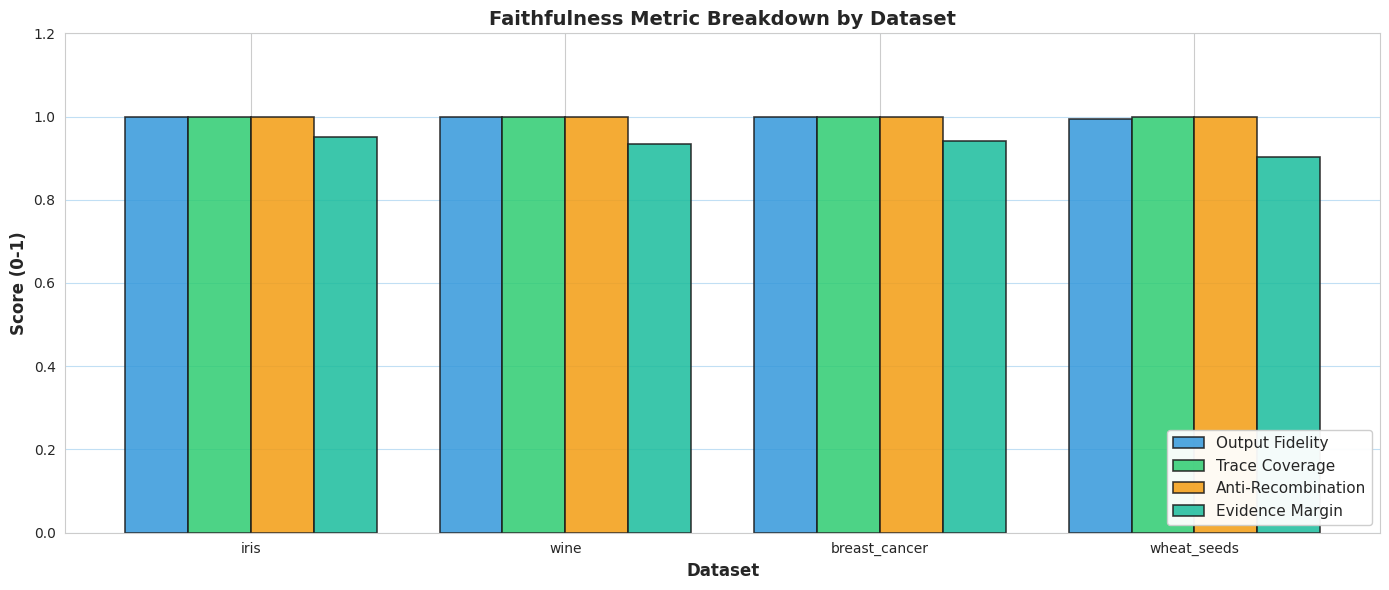

In [15]:
# Grouped bar chart with DPG color scheme
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(metrics_df))
width = 0.2

metric_labels = ['Output Fidelity', 'Trace Coverage', 'Anti-Recombination', 'Evidence Margin']
metric_data = [
    metrics_df['Output Fidelity'],
    metrics_df['Trace Coverage'],
    metrics_df['Recombination Rate'],
    metrics_df['Evidence Margin'],
]

# DPG official colors for metrics
colors_metrics = ['#3498DB', '#2ECC71', '#F39C12', '#1ABC9C']

for i, (label, data, color) in enumerate(zip(metric_labels, metric_data, colors_metrics)):
    offset = (i - 1.5) * width
    ax.bar(x + offset, data, width, label=label, color=color, alpha=0.85, edgecolor='#1C1C1C', linewidth=1.2)

ax.set_xlabel('Dataset', fontsize=12, fontweight='bold')
ax.set_ylabel('Score (0-1)', fontsize=12, fontweight='bold')
ax.set_title('Faithfulness Metric Breakdown by Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Dataset'])
ax.set_ylim(0, 1.2)
ax.legend(loc='lower right', fontsize=11, framealpha=0.95)
ax.grid(axis='y', alpha=0.3, color='#3498DB')

plt.tight_layout()
plt.show()


## Result 3: Per-Sample Distribution Analysis

Not all samples have equal explanation quality. Let's examine the distribution of confidence metrics within each dataset.

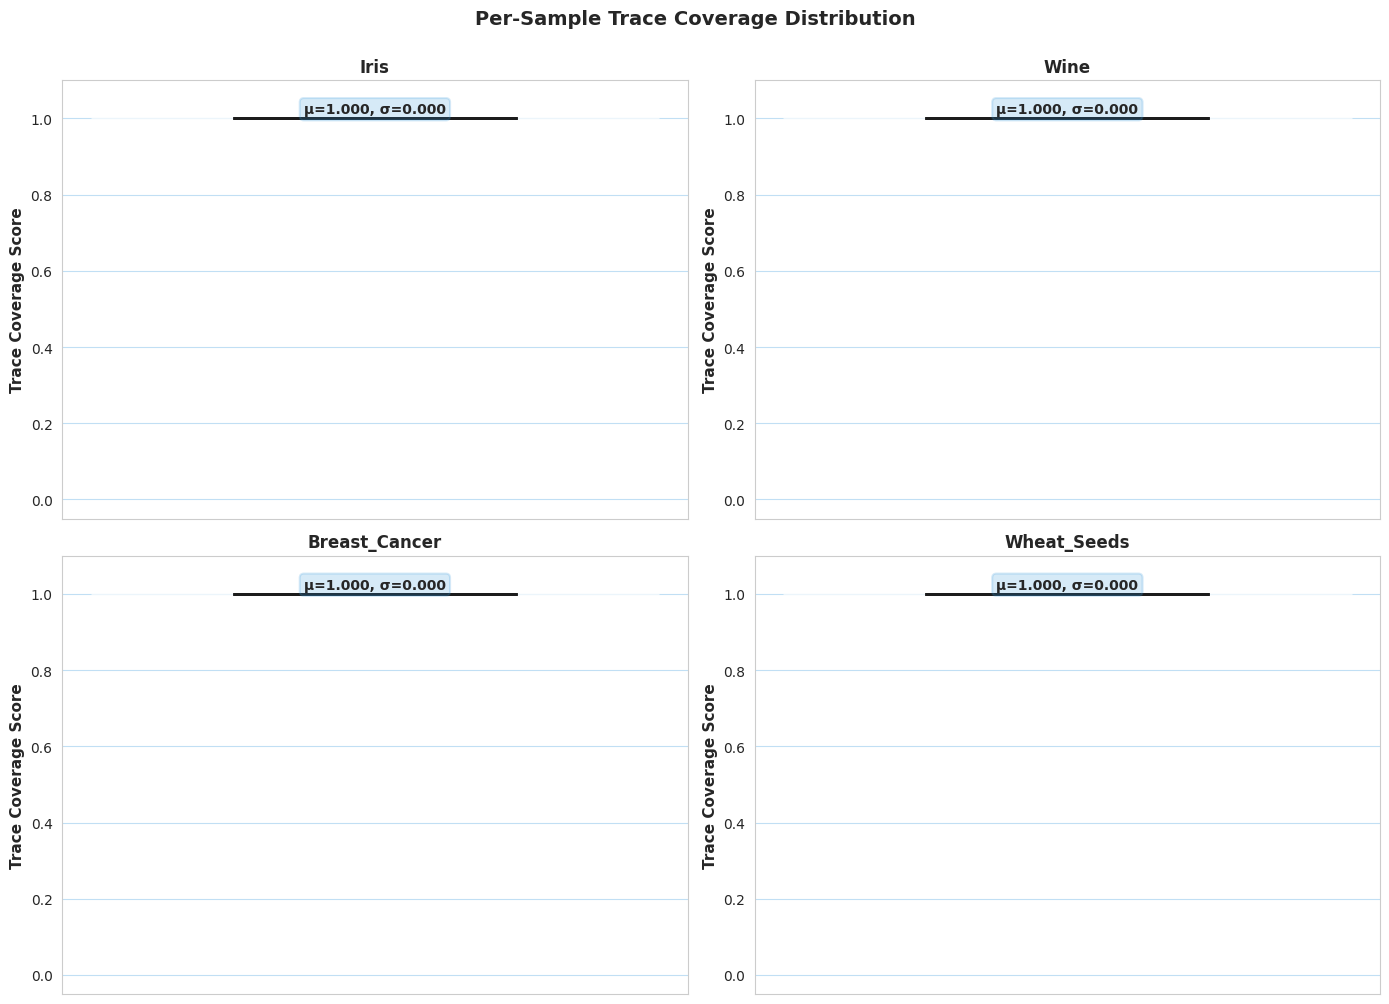

In [16]:
# Visualize per-sample trace coverage scores with DPG styling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

dataset_names = list(results.keys())

for idx, dataset_name in enumerate(dataset_names):
    res = results[dataset_name]
    per_sample_df = res['per_sample']
    
    ax = axes[idx]
    
    # Violin plot for trace coverage
    data_to_plot = per_sample_df['trace_coverage_score'].dropna()
    parts = ax.violinplot(
        [data_to_plot.values],
        positions=[0],
        widths=0.7,
        showmeans=True,
        showmedians=True,
    )
    
    # Color the violin plot with DPG primary color
    for pc in parts['bodies']:
        pc.set_facecolor('#3498DB')
        pc.set_alpha(0.7)
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
        if partname in parts:
            vp = parts[partname]
            vp.set_edgecolor('#1C1C1C')
            vp.set_linewidth(2)
    
    ax.set_ylabel('Trace Coverage Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.title()}', fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylim(-0.05, 1.1)
    ax.grid(axis='y', alpha=0.3, color='#3498DB')
    
    # Add statistics box with DPG styling
    mean_val = data_to_plot.mean()
    ax.text(0.5, 0.95, f'μ={mean_val:.3f}, σ={data_to_plot.std():.3f}',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='#3498DB', alpha=0.2, edgecolor='#3498DB', linewidth=1.5),
            fontsize=10, fontweight='bold')

fig.suptitle('Per-Sample Trace Coverage Distribution', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


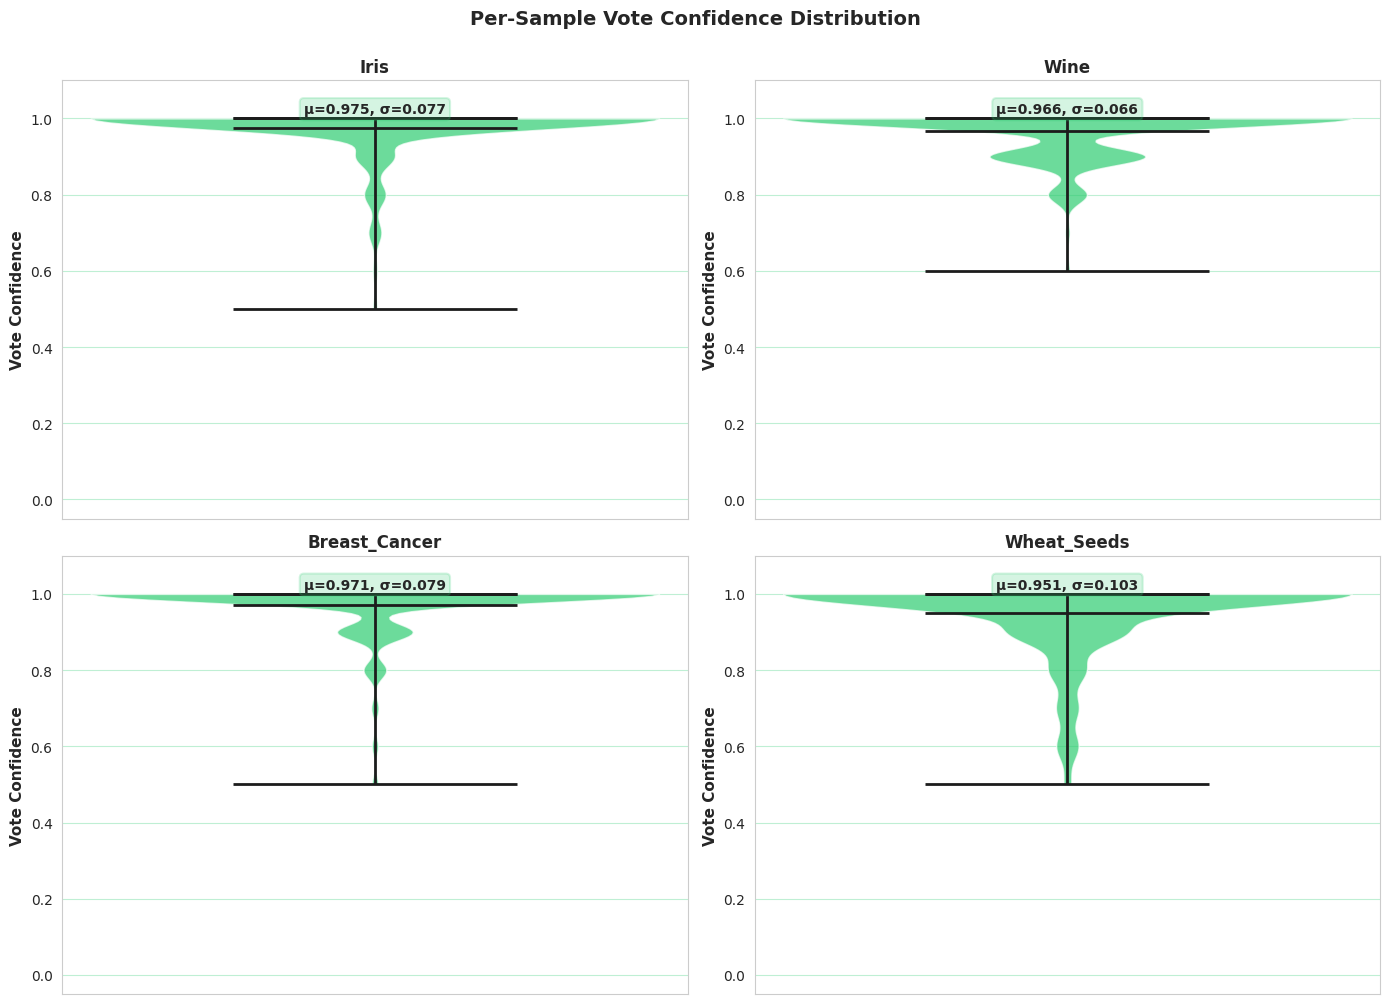

In [17]:
# Visualize per-sample vote confidence scores with DPG styling
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, dataset_name in enumerate(dataset_names):
    res = results[dataset_name]
    per_sample_df = res['per_sample']
    
    ax = axes[idx]
    
    # Violin plot for vote confidence
    data_to_plot = per_sample_df['vote_confidence'].dropna()
    parts = ax.violinplot(
        [data_to_plot.values],
        positions=[0],
        widths=0.7,
        showmeans=True,
        showmedians=True,
    )
    
    # Color the violin plot with DPG success color
    for pc in parts['bodies']:
        pc.set_facecolor('#2ECC71')
        pc.set_alpha(0.7)
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
        if partname in parts:
            vp = parts[partname]
            vp.set_edgecolor('#1C1C1C')
            vp.set_linewidth(2)
    
    ax.set_ylabel('Vote Confidence', fontsize=11, fontweight='bold')
    ax.set_title(f'{dataset_name.title()}', fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_ylim(-0.05, 1.1)
    ax.grid(axis='y', alpha=0.3, color='#2ECC71')
    
    # Add statistics box with DPG styling
    mean_val = data_to_plot.mean()
    ax.text(0.5, 0.95, f'μ={mean_val:.3f}, σ={data_to_plot.std():.3f}',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='#2ECC71', alpha=0.2, edgecolor='#2ECC71', linewidth=1.5),
            fontsize=10, fontweight='bold')

fig.suptitle('Per-Sample Vote Confidence Distribution', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


## Interpretation: What Do These Results Mean?

> **Note:** Faithfulness does not guarantee correctness. A highly faithful explanation can still explain an incorrect prediction. Conversely, an unfaithful explanation might get lucky and align with a correct prediction.

### High Faithfulness

**When composite score ≥ 0.70:**
- The DPG explanation reliably predicts what the model predicts (output fidelity is high)
- The decision paths extracted by DPG cover the actual execution paths (high trace coverage)
- Few spurious or invented edges in the explanation (low recombination)
- The evidence strongly supports the winning class (high evidence margin)

**When to trust:** These explanations are safe to rely on for understanding the model's decision-making. Use them to debug the model or audit its reasoning.

---

### Moderate Faithfulness

**When composite score 0.50–0.70:**
- The explanation captures the general decision direction but may miss fine details
- Some samples have clear explanations, others don't
- Possible sources: high-dimensional data, complex decision boundaries, or ensemble disagreement

**When to use:** Take these explanations with a grain of salt. Use them for exploratory understanding but verify critical decisions against the raw model predictions.

---

### Low Faithfulness

**When composite score < 0.50:**
- The DPG explanation often diverges from the model's actual prediction or decision path
- Possible sources: the model relies on complex feature interactions that DPG cannot easily express as predicates, or the execution trace is highly volatile across samples

**When to use cautiously:** These explanations may mislead. Consider:
- Re-fitting with different DPG config (e.g., less aggressive pruning)
- Using complementary explainability methods (SHAP, LIME)
- Investigating whether your data is amenable to predicate-based explanations

### Per-Sample Variation

Notice that within each dataset, trace coverage and vote confidence vary significantly from sample to sample. This is expected:

- **High variation:** Not all regions of your feature space are equally explainable. Outliers or edge cases may have lower explanation quality.
- **Clustered low values:** Suggests a subset of samples that the model finds ambiguous or that lie in complex decision regions.
- **Clustered high values:** Indicates that most samples fall into well-defined decision regions with stable, interpretable rules.

## Summary and Recommendations

**Key findings:**

In [18]:
# Print comprehensive summary
print("="*70)
print("EXPLANATION FAITHFULNESS BENCHMARK SUMMARY")
print("="*70)

for dataset_name in sorted(results.keys()):
    res = results[dataset_name]
    score = res['faithfulness_score']
    
    print(f"\n{dataset_name.upper()}")
    print("-" * 50)
    print(f"  Composite Faithfulness Score: {score:.4f}", end="")
    if score >= 0.70:
        print(" [✓ HIGH]")
    elif score >= 0.50:
        print(" [◐ MODERATE]")
    else:
        print(" [✗ LOW]")
    
    print(f"  Output Fidelity:          {res['output_fidelity']:.4f}")
    print(f"  Trace Coverage:           {res['mean_trace_coverage_score']:.4f}")
    print(f"  Anti-Recombination:       {1 - res['mean_recombination_rate']:.4f}")
    print(f"  Evidence Margin:          {res['mean_evidence_score_margin']:.4f}")
    print(f"  Successful evaluations:   {res['n_successful']} / {res['n_samples']}")

print(f"\n{'='*70}")

EXPLANATION FAITHFULNESS BENCHMARK SUMMARY

BREAST_CANCER
--------------------------------------------------
  Composite Faithfulness Score: 0.9907 [✓ HIGH]
  Output Fidelity:          0.9982
  Trace Coverage:           1.0000
  Anti-Recombination:       1.0000
  Evidence Margin:          0.9424
  Successful evaluations:   569 / 569

IRIS
--------------------------------------------------
  Composite Faithfulness Score: 0.9926 [✓ HIGH]
  Output Fidelity:          1.0000
  Trace Coverage:           1.0000
  Anti-Recombination:       1.0000
  Evidence Margin:          0.9507
  Successful evaluations:   150 / 150

WHEAT_SEEDS
--------------------------------------------------
  Composite Faithfulness Score: 0.9837 [✓ HIGH]
  Output Fidelity:          0.9952
  Trace Coverage:           1.0000
  Anti-Recombination:       1.0000
  Evidence Margin:          0.9024
  Successful evaluations:   210 / 210

WINE
--------------------------------------------------
  Composite Faithfulness Score: 0.9

**Recommendations:**

1. **For high-faithfulness datasets:** Use DPG explanations confidently for model debugging, auditing, and regulatory compliance. The extracted decision rules are reliable.

2. **For moderate-faithfulness datasets:** Combine DPG with other explainability methods. Use DPG to capture the global decision structure, and use SHAP or LIME for sample-specific feature importance.

3. **For low-faithfulness datasets:** Reconsider whether your model is interpretable by design. Consider:
   - Simpler models (decision trees, logistic regression, rule-based classifiers)
   - Feature engineering to make relationships more linear/separable
   - Ensemble methods with better agreement (e.g., fewer, deeper trees)

4. **Per-sample diagnostics:** Always check the `vote_confidence` and `trace_coverage_score` for individual samples. Low scores indicate uncertain or complex predictions that deserve manual review.

5. **Iterative improvement:** After getting a faithfulness report:
   - Identify samples with low trace coverage or high recombination
   - Visualize their feature spaces and decision boundaries
   - Determine if they're outliers, boundary cases, or indicative of model confusion